In [ ]:
import sys
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from modeling.model_data import load_model_ready_data, create_xy  # type: ignore
from modeling.evaluation import calculate_regression_metrics, create_prediction_frame  # type: ignore

RESULTS_DIR = PROJECT_ROOT / "output" / "results"
MODELS_DIR = PROJECT_ROOT / "output" / "models"
OUTPUT_DIR = PROJECT_ROOT / "output" / "comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid")
FIGSIZE = (12, 7)

In [2]:
results = pd.read_csv(RESULTS_DIR / "baseline_results.csv")
results = results.sort_values("r2", ascending=False).reset_index(drop=True)
results

,model,feature_set,target,training_time_seconds,best_iteration,mae,rmse,r2,mae_eur,rmse_eur
0,xgboost,tabular_spatial,log_price,2.319606,831.0,0.249827,0.433946,0.606634,73.359961,602.836601
1,xgboost,tabular,log_price,2.736137,1054.0,0.247318,0.437090,0.600913,73.036538,603.120881
2,xgboost,tabular_sentiment,log_price,2.774780,908.0,0.250666,0.437497,0.600170,73.593544,602.880542
3,xgboost,all,log_price,8.709536,679.0,0.252311,0.438949,0.597513,73.700682,603.775220
4,xgboost,tabular_text,log_price,8.661808,711.0,0.252554,0.440761,0.594183,73.778413,603.767535
5,random_forest,tabular_spatial,log_price,5.862107,NaN,0.268858,0.461552,0.554995,75.945324,604.623228
6,random_forest,tabular_text,log_price,10.577244,NaN,0.272237,0.463246,0.551722,76.619758,604.534310
7,random_forest,tabular,log_price,5.261511,NaN,0.271028,0.463688,0.550866,76.076131,604.356549
8,ridge,tabular_text,log_price,0.191971,NaN,0.293811,0.479065,0.520582,79.158973,605.468531
9,ridge,tabular,log_price,0.045723,NaN,0.309805,0.492166,0.494003,81.728886,606.411481


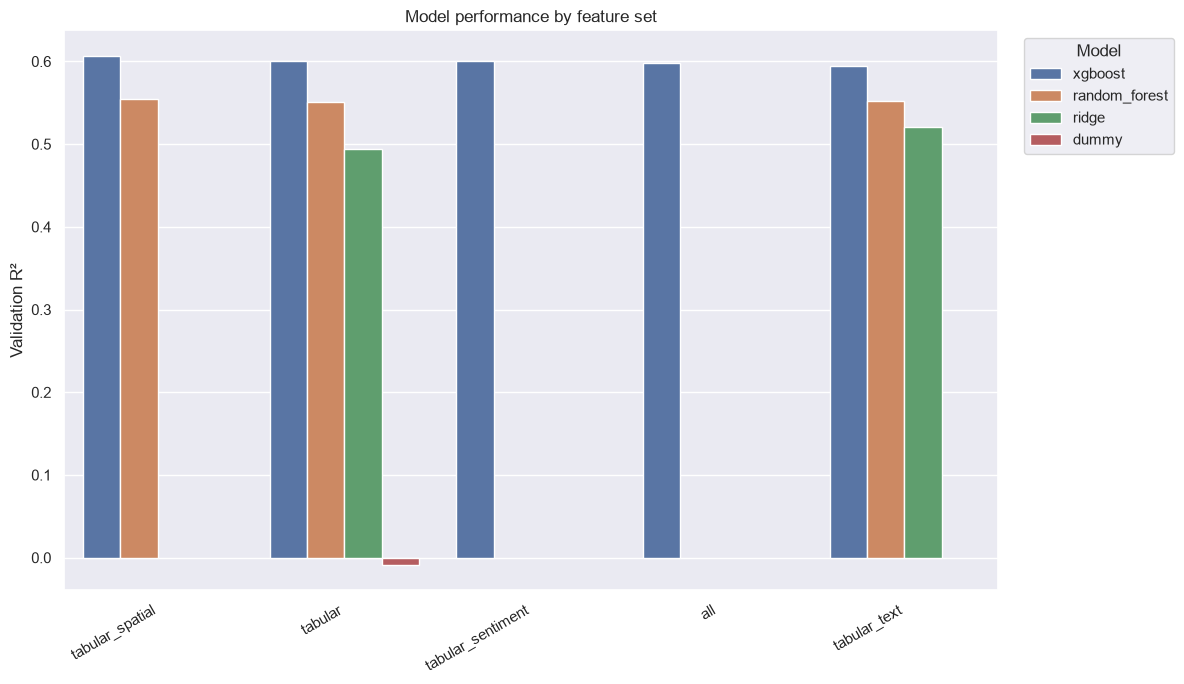

In [13]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.barplot(data=results, x="feature_set", y="r2", hue="model", ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Validation R\u00b2")
ax.set_title("Model performance by feature set")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [15]:
best = results.iloc[0]
print(f"Best result: {best['model']} on '{best['feature_set']}'")
print(f"  R\u00b2       = {best['r2']:.4f}")
print(f"  RMSE     = {best['rmse']:.4f} (log-price)")
print(f"  MAE EUR  = {best['mae_eur']:.2f}")

Best result: xgboost on 'tabular_spatial'
  R²       = 0.6066
  RMSE     = 0.4339 (log-price)
  MAE EUR  = 73.36


### held-out test performance

In [ ]:
_, _, test_df = load_model_ready_data()

best_model_name = best["model"]
best_feature_set = best["feature_set"]
experiment_name = f"{best_model_name}_{best_feature_set}"
model_path = MODELS_DIR / f"{experiment_name}.joblib"

X_test, y_test = create_xy(test_df, target="log_price", feature_set=best_feature_set)

loaded = joblib.load(model_path)

if isinstance(loaded, dict):
    X_test_processed = loaded["preprocessor"].transform(X_test)
    test_pred = loaded["model"].predict(X_test_processed)
else:
    test_pred = loaded.predict(X_test)

test_metrics = calculate_regression_metrics(y_test, test_pred, target="log_price")

print(f"Final test performance - {best_model_name} on '{best_feature_set}':")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Final test performance — xgboost on 'tabular_spatial':
  mae: 0.2356
  rmse: 0.3989
  r2: 0.6405
  mae_eur: 84.4965
  rmse_eur: 1342.2811


In [ ]:
pred_frame = create_prediction_frame(listing_ids=test_df["listing_id"], y_true=y_test, y_pred=test_pred, target="log_price")

pred_frame = pred_frame.merge(test_df[["listing_id", "neighborhood_group"]], on="listing_id", how="left")
pred_frame.head()

,listing_id,y_true,y_pred,residual,absolute_error,true_price_eur,predicted_price_eur,absolute_error_eur,neighborhood_group
0,1428029739775347606,5.081404,4.879065,0.202340,0.202340,160.0,130.507584,29.492416,Pankow
1,1466672871084179689,4.317488,4.603540,-0.286052,0.286052,74.0,98.837105,24.837105,Charlottenburg-Wilm.
2,48732044,4.744932,4.972109,-0.227177,0.227177,114.0,143.331009,29.331009,Friedrichshain-Kreuzberg
3,38038108,4.574711,4.463215,0.111496,0.111496,96.0,85.766006,10.233994,Friedrichshain-Kreuzberg
4,979526676093486333,5.332719,5.156668,0.176051,0.176051,206.0,172.585052,33.414948,Treptow - Köpenick


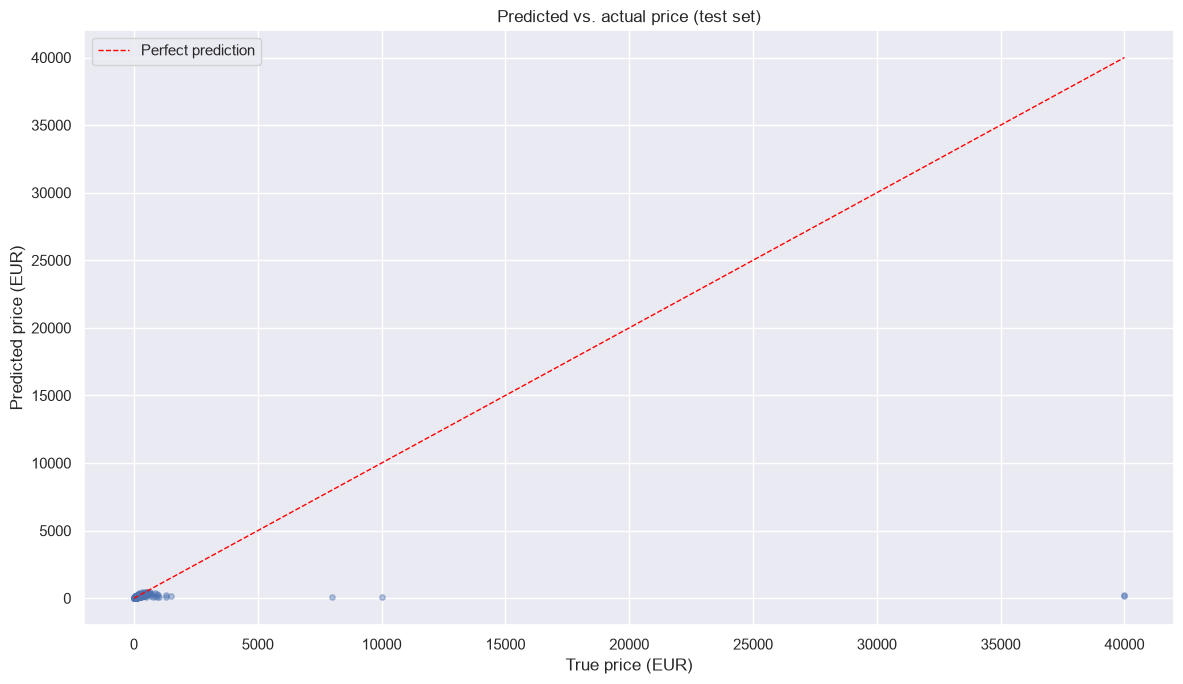

In [17]:
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(pred_frame["true_price_eur"], pred_frame["predicted_price_eur"], alpha=0.4, s=15)

lims = [0, pred_frame["true_price_eur"].max()]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Perfect prediction")

ax.set_xlabel("True price (EUR)")
ax.set_ylabel("Predicted price (EUR)")
ax.set_title("Predicted vs. actual price (test set)")
ax.legend()

plt.tight_layout()
plt.show()

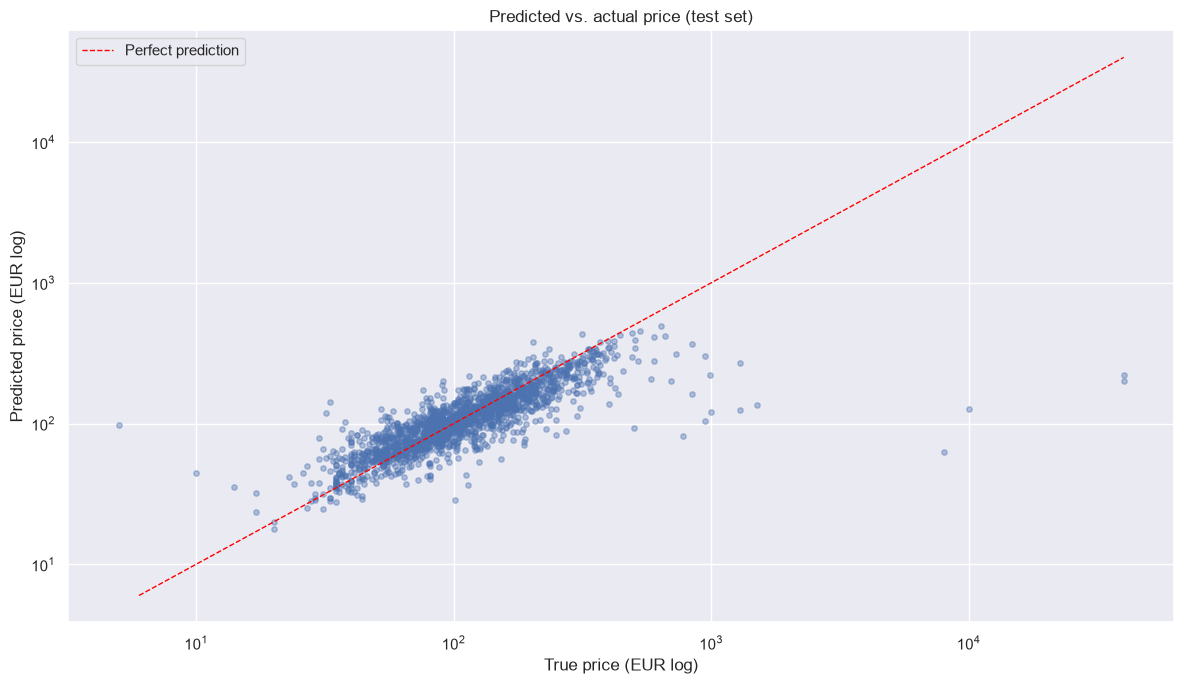

In [18]:
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(pred_frame["true_price_eur"], pred_frame["predicted_price_eur"], alpha=0.4, s=15)

lims = [pred_frame["true_price_eur"].min() + 1, pred_frame["true_price_eur"].max()]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Perfect prediction")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("True price (EUR log)")
ax.set_ylabel("Predicted price (EUR log)")
ax.set_title("Predicted vs. actual price (test set)")
ax.legend()

plt.tight_layout()
plt.show()

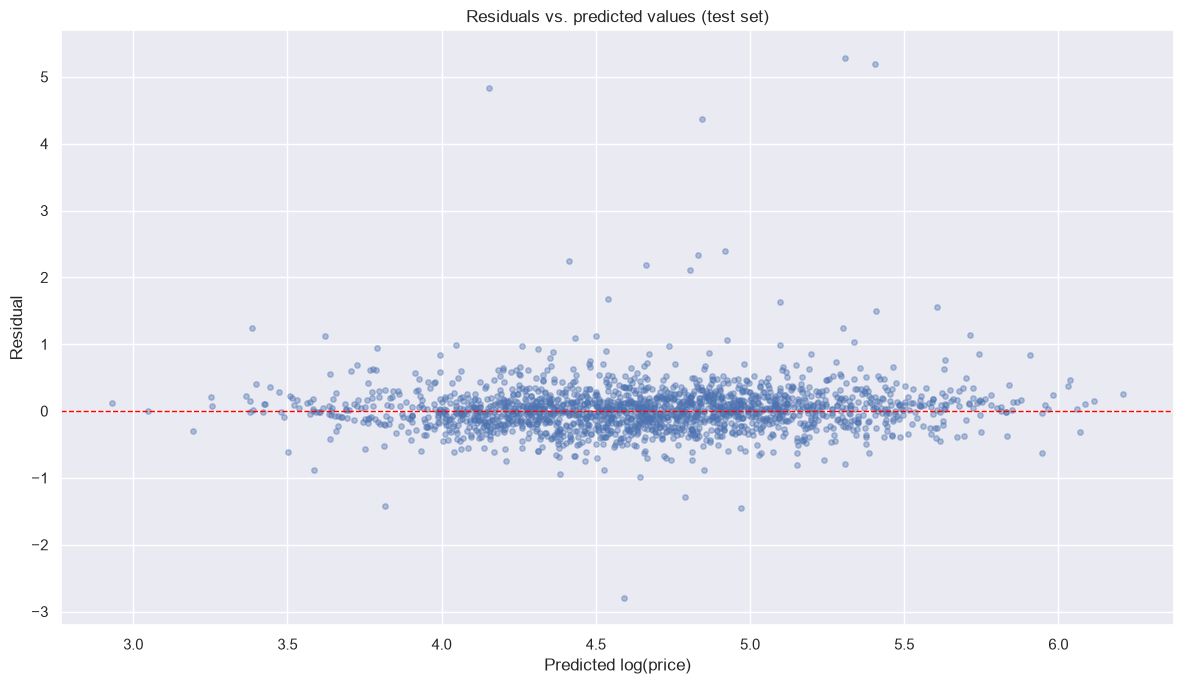

In [20]:
fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(pred_frame["y_pred"], pred_frame["residual"], alpha=0.4, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1)

ax.set_xlabel("Predicted log(price)")
ax.set_ylabel("Residual")
ax.set_title("Residuals vs. predicted values (test set)")

plt.tight_layout()
plt.show()

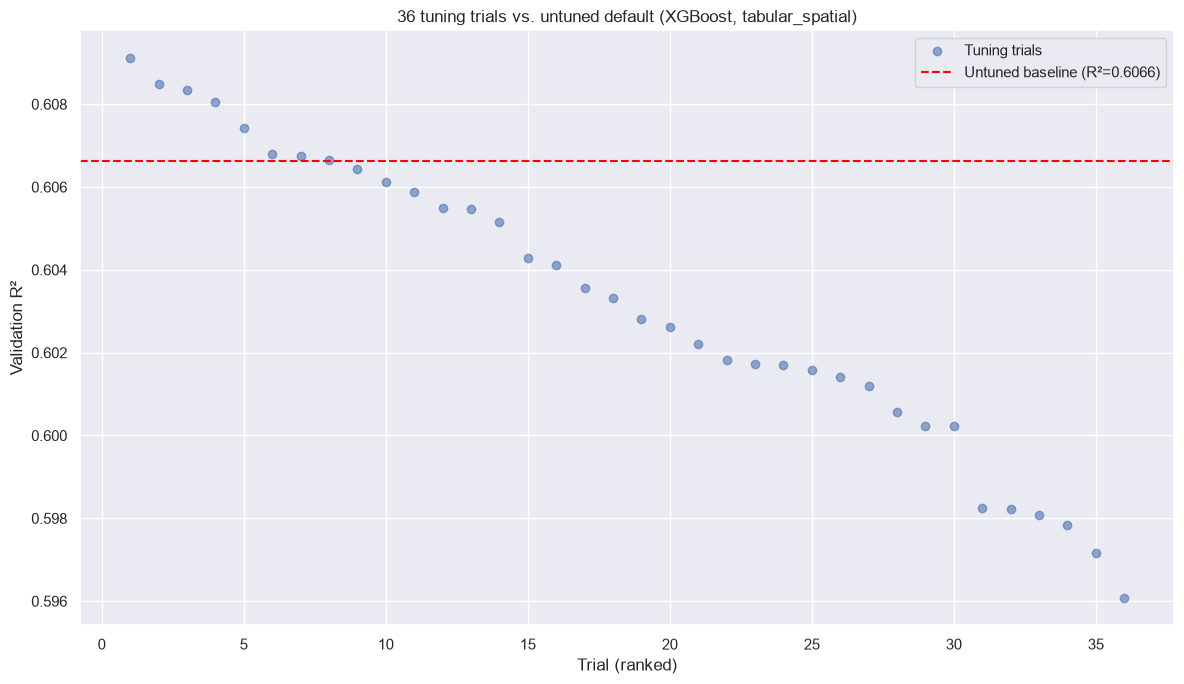

Untuned baseline ranks #9 out of 37


In [ ]:
tuning = pd.read_csv(PROJECT_ROOT / "output" / "tuning" / "tabular_spatial_xgboost_tuning_results.csv")
tuning = tuning.sort_values("rmse").reset_index(drop=True)
best_tuned = tuning.iloc[0]

baseline = results[(results["model"] == "xgboost") & (results["feature_set"] == "tabular_spatial")].iloc[0]

fig, ax = plt.subplots(figsize=FIGSIZE)

sorted_r2 = tuning["r2"].sort_values(ascending=False).values
ax.scatter(range(1, len(sorted_r2) + 1), sorted_r2, alpha=0.6, label="Tuning trials")
ax.axhline(baseline["r2"], color="red", linestyle="--", label=f"Untuned baseline (R²={baseline['r2']:.4f})")

ax.set_xlabel("Trial")
ax.set_ylabel("Validation R²")
ax.set_title("36 tuning trials vs. untuned default (XGBoost, tabular_spatial)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Untuned baseline ranks #{(tuning['r2'] > baseline['r2']).sum() + 1} out of {len(tuning) + 1}")